In [2]:
# import libraries 
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


/home/susan/mof-co2-adsorption/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('/home/susan/mof-co2-adsorption/data/processed/data_clean_v2')
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31234 entries, 0 to 31233
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   filename                  31234 non-null  object 
 1   lcd                       31234 non-null  float64
 2   pld                       31234 non-null  float64
 3   void_fraction             31234 non-null  float64
 4   surface_area_m2g          31234 non-null  float64
 5   mofid                     27706 non-null  object 
 6   CO2_uptake_0.01bar_molkg  31234 non-null  float64
 7   CO2_uptake_0.05bar_molkg  31234 non-null  float64
 8   CO2_uptake_0.1bar_molkg   31234 non-null  float64
 9   CO2_uptake_0.5bar_molkg   31234 non-null  float64
 10  CO2_uptake_2.5bar_molkg   31234 non-null  float64
dtypes: float64(9), object(2)
memory usage: 2.6+ MB
None


In [4]:
import random
import numpy as np

SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
# Store the four structural features used in the relationship analysis.
feature_columns = ["lcd", "pld", "void_fraction", "surface_area_m2g"]

# Store the five CO2-uptake targets in increasing pressure order.
target_columns = ["CO2_uptake_0.05bar_molkg",
                "CO2_uptake_0.1bar_molkg",
                "CO2_uptake_0.5bar_molkg",
                "CO2_uptake_2.5bar_molkg"]
# Select only the required features and targets
features = df[feature_columns].copy()
targets = df[target_columns].copy()
# split data
# temp simply means temporary.
# X_train: 60%
# X_temp: 40%

# Shuffle the data only when we create the train/validation/test split—before standardization and before training any model.
X_train, X_temp, y_train, y_temp = train_test_split(features , targets, test_size = 0.4 ,
                                                         shuffle=True,
                                                         random_state=SEED)

# Train: 60%
# Validation: 20%
# Test: 20%
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    shuffle=True,
    random_state=SEED
)
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Testing:", X_test.shape, y_test.shape)

print("\nMissing values in training features:")
print(X_train.isna().sum())                

Training: (18740, 4) (18740, 4)
Validation: (6247, 4) (6247, 4)
Testing: (6247, 4) (6247, 4)

Missing values in training features:
lcd                 0
pld                 0
void_fraction       0
surface_area_m2g    0
dtype: int64


In [5]:
# Run the model for best rf at all pressure
# Dictionary to store the trained model for each pressure
models = {}
for target in target_columns:
    # create a new Randomforestregressor
    model_rf = RandomForestRegressor ( n_estimators=200,    
                max_depth=None,          
                min_samples_split=5,     
                min_samples_leaf=4,     
                random_state=SEED,
                n_jobs=-1    ) 
    
    # Train the model for Co2 pressure
    model_rf.fit(X_train, y_train[target])
    # Store the trained model
    models[target] = model_rf
    print(f"Model trained for: {target}")


Model trained for: CO2_uptake_0.05bar_molkg
Model trained for: CO2_uptake_0.1bar_molkg
Model trained for: CO2_uptake_0.5bar_molkg
Model trained for: CO2_uptake_2.5bar_molkg


In [7]:
# Calculate SHAP values for every pressure-specific model.
X_test_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=SEED,
)

explainers = {}
shap_values_by_target = {}

for target in target_columns:
    explainer = shap.TreeExplainer(models[target], X_train)
    shap_values_by_target[target] = explainer(X_test_sample, check_additivity=False,)
    explainers[target] = explainer
    print(f"SHAP values calculated for: {target}")

# Example plot for one pressure:
# shap.plots.beeswarm(shap_values_by_target[target_columns[0]])

Background dataset has 18740 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18740 when initializing the masker.


 99%|===================| 987/1000 [00:51<00:00]        Background dataset has 18740 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18740 when initializing the masker.


SHAP values calculated for: CO2_uptake_0.05bar_molkg


 99%|===================| 989/1000 [00:53<00:00]        Background dataset has 18740 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18740 when initializing the masker.


SHAP values calculated for: CO2_uptake_0.1bar_molkg


100%|===================| 998/1000 [00:54<00:00]        Background dataset has 18740 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18740 when initializing the masker.


SHAP values calculated for: CO2_uptake_0.5bar_molkg


100%|===================| 996/1000 [00:48<00:00]        

SHAP values calculated for: CO2_uptake_2.5bar_molkg



CO2_uptake_0.05bar_molkg


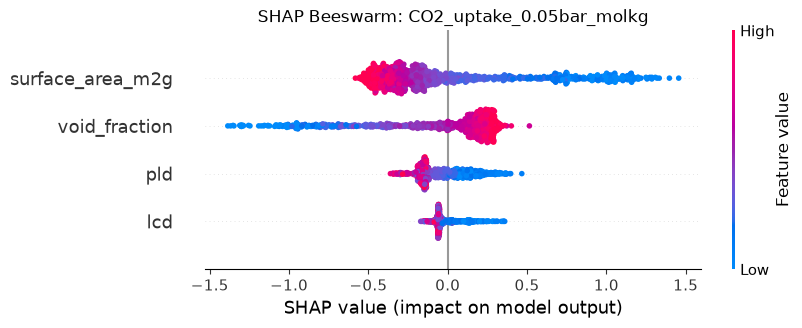

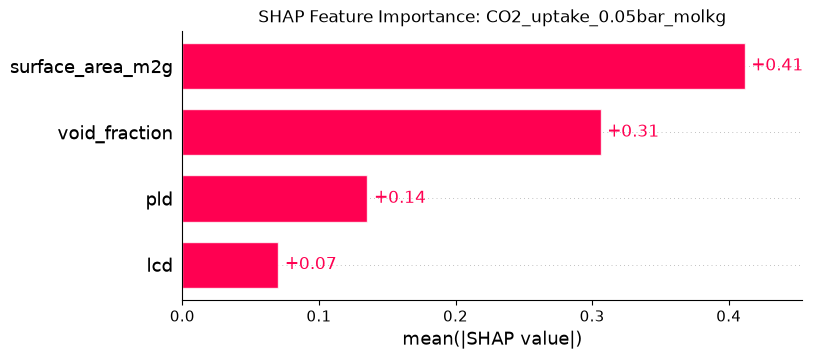


CO2_uptake_0.1bar_molkg


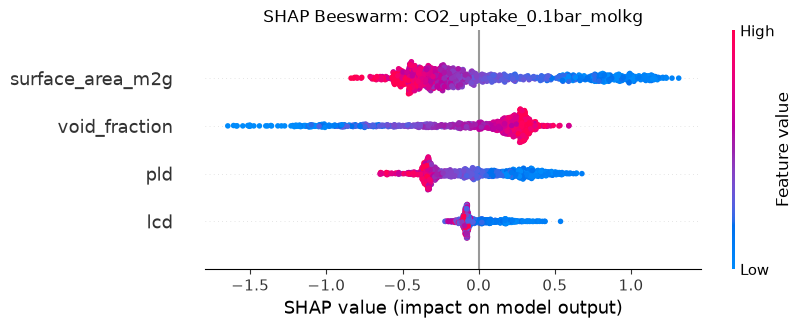

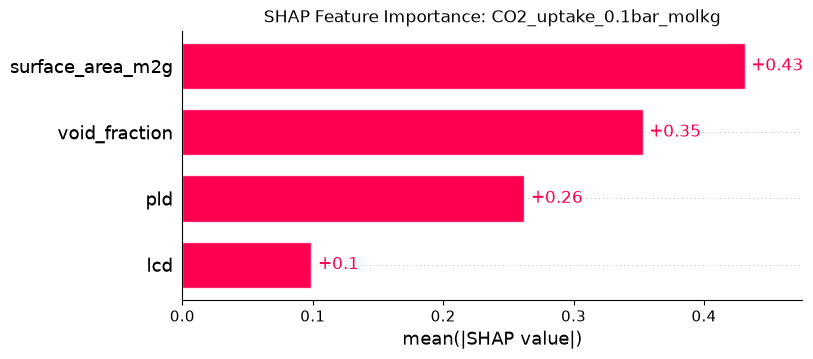


CO2_uptake_0.5bar_molkg


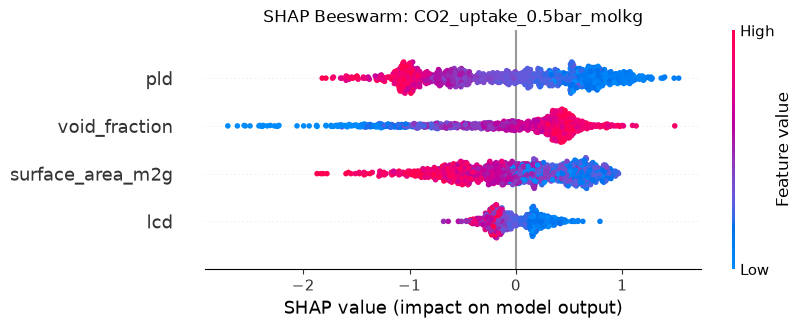

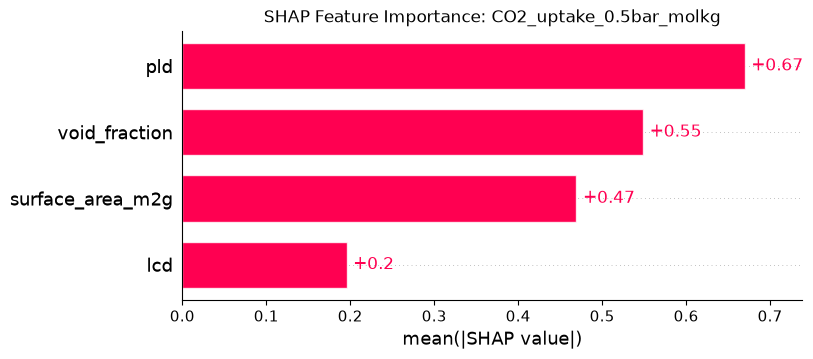


CO2_uptake_2.5bar_molkg


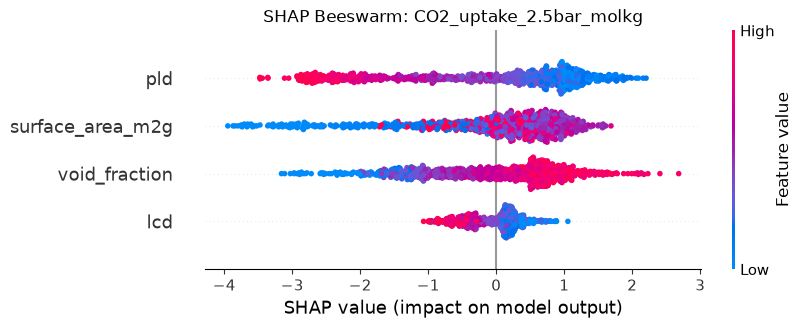

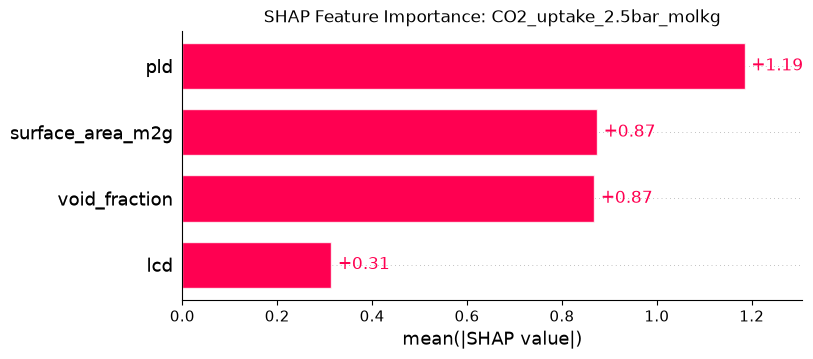

In [8]:
import matplotlib.pyplot as plt

for target in target_columns:
    print(f"\n{target}")

    # Global explanation: importance and direction
    shap.plots.beeswarm(
        shap_values_by_target[target],
        max_display=len(feature_columns),
        show=False,
    )
    plt.title(f"SHAP Beeswarm: {target}")
    plt.show()

    # Global explanation: mean absolute SHAP importance
    shap.plots.bar(
        shap_values_by_target[target],
        max_display=len(feature_columns),
        show=False,
    )
    plt.title(f"SHAP Feature Importance: {target}")
    plt.show()

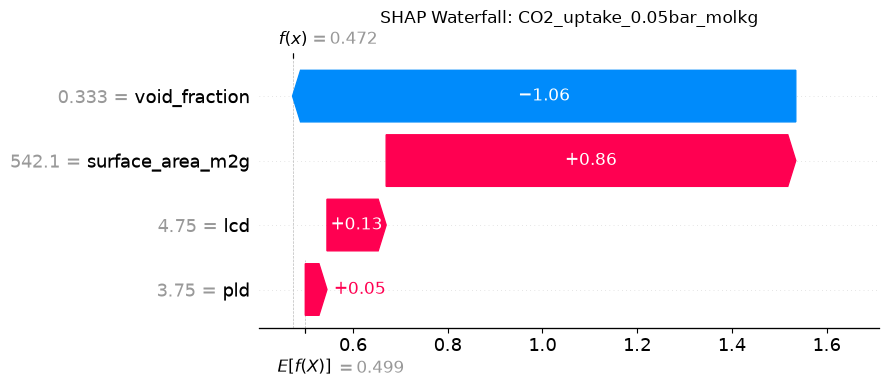

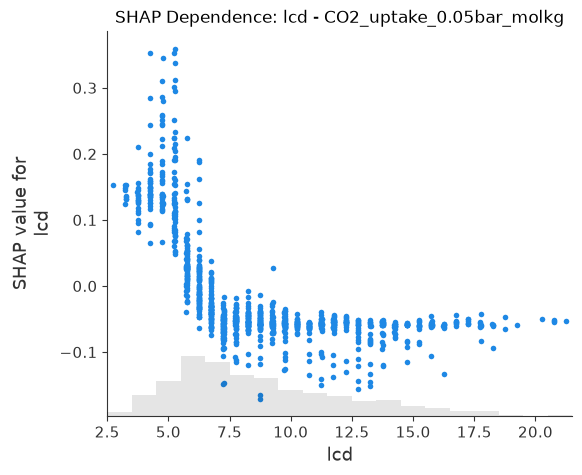

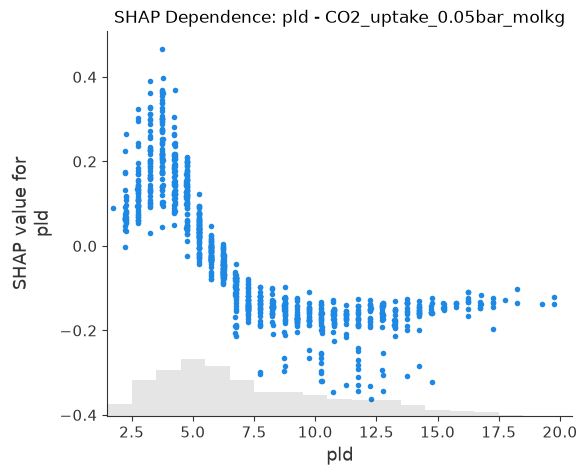

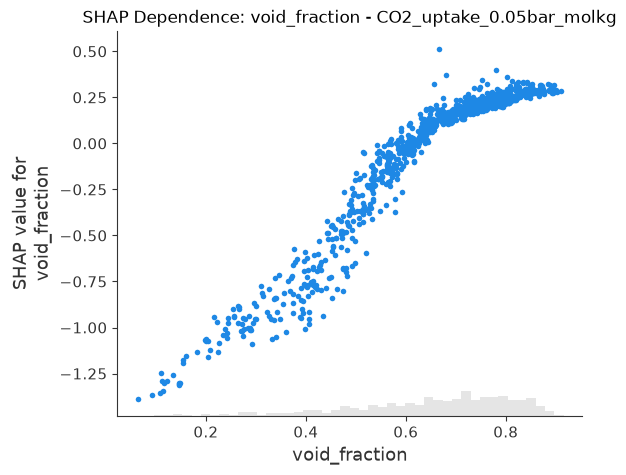

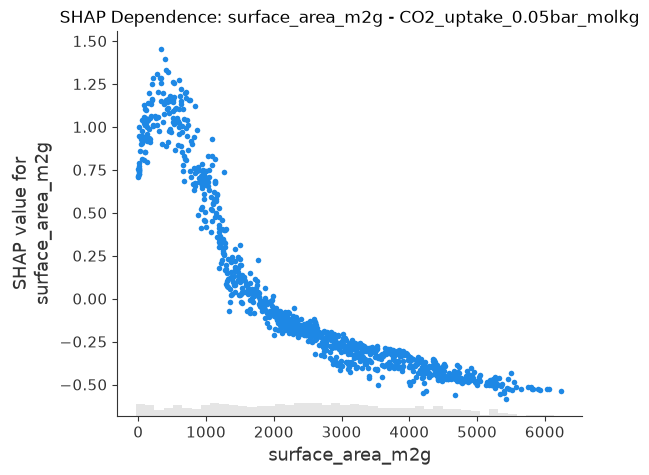

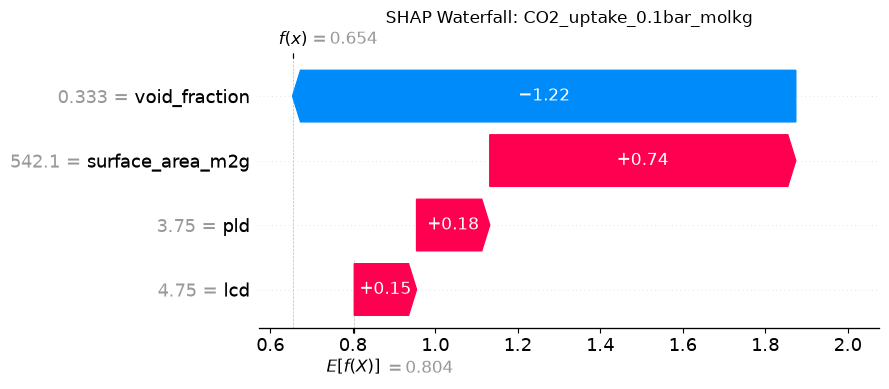

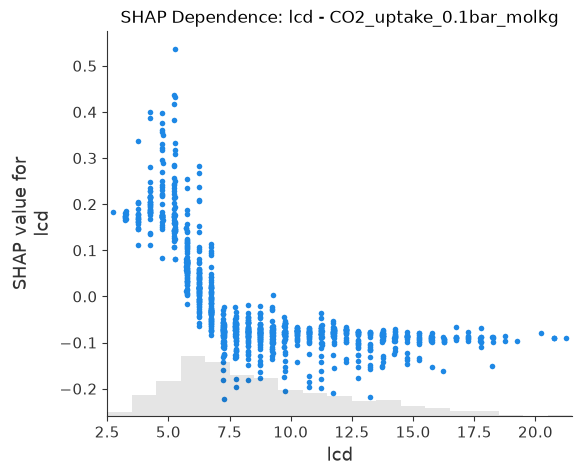

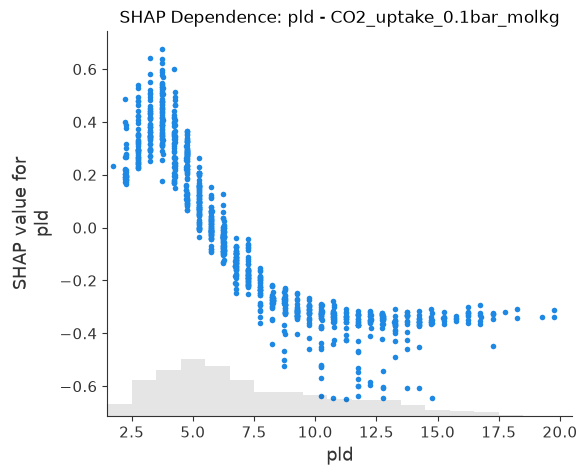

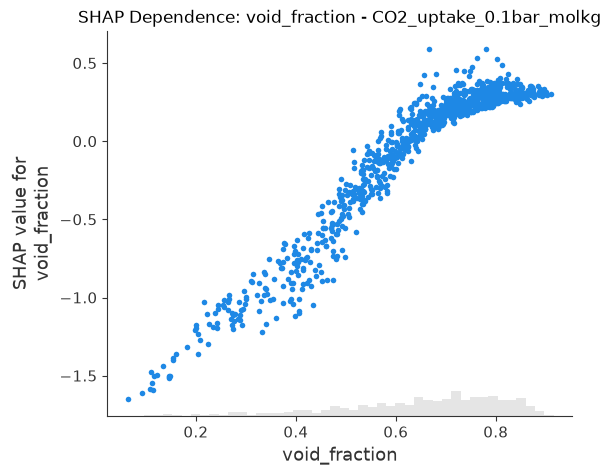

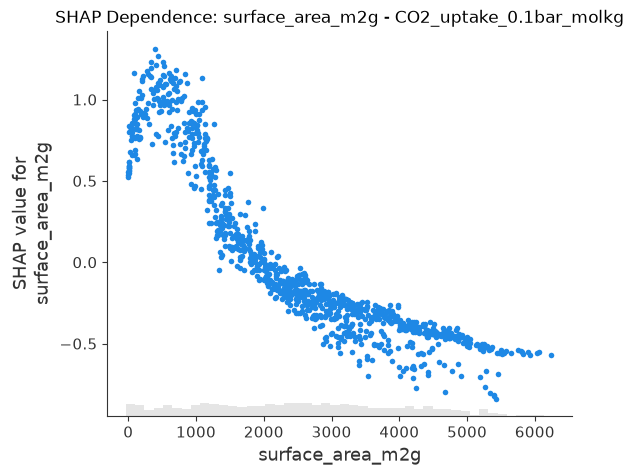

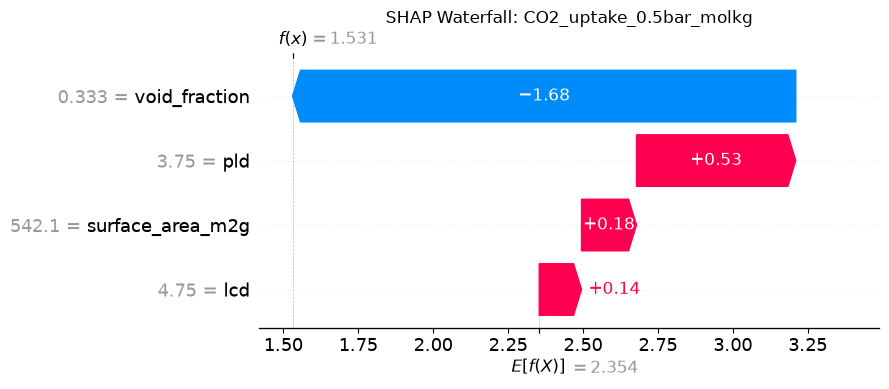

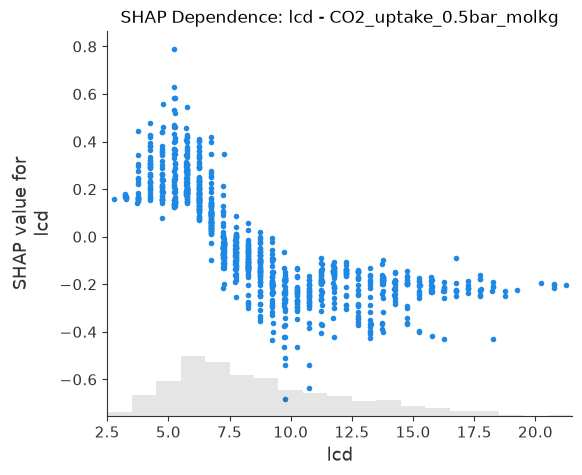

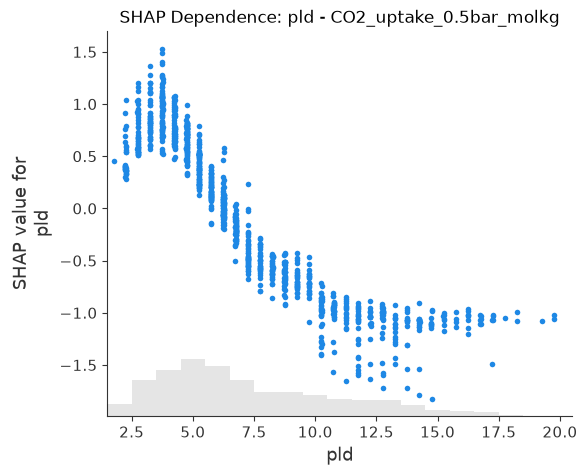

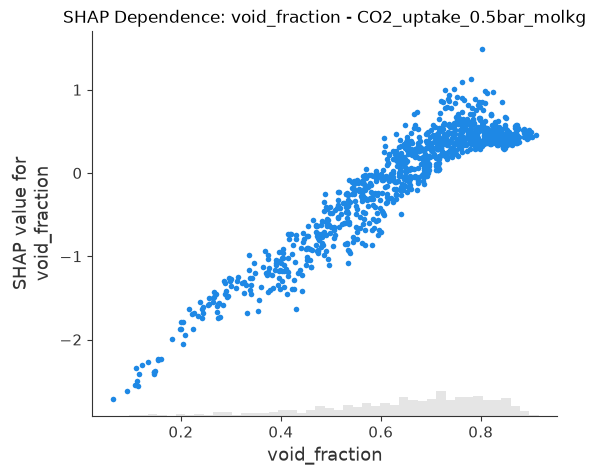

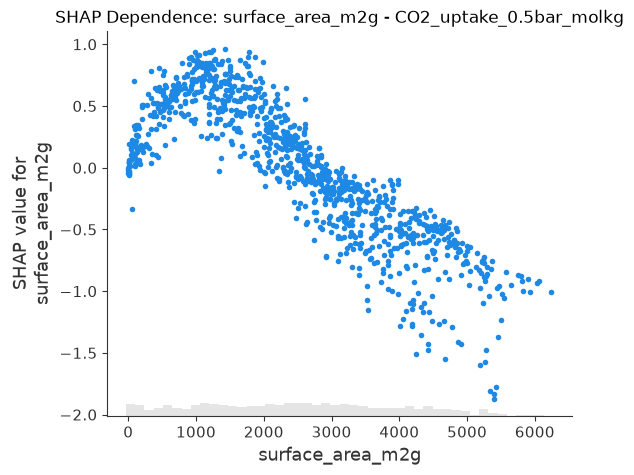

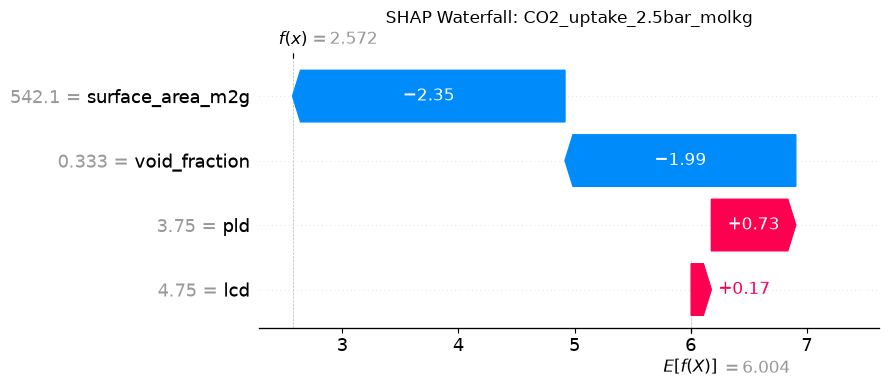

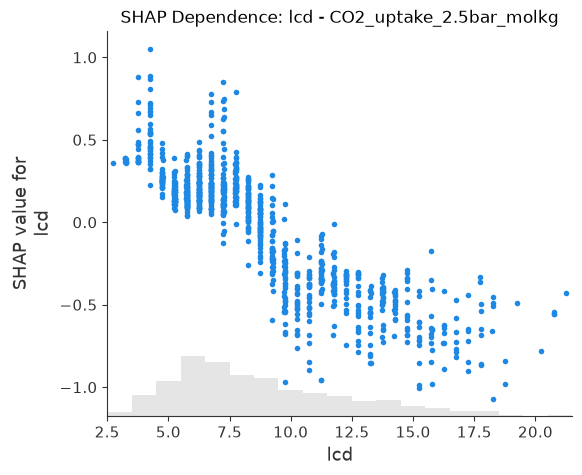

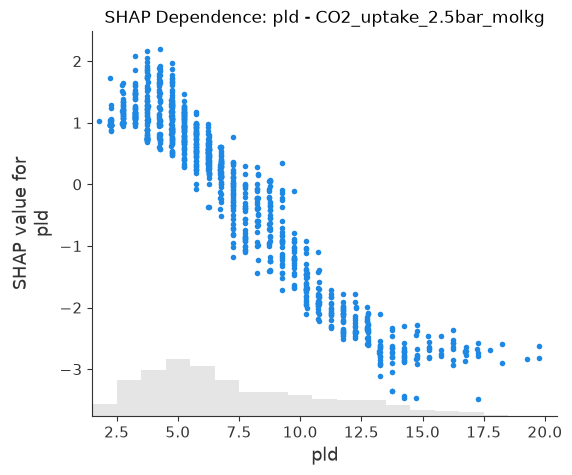

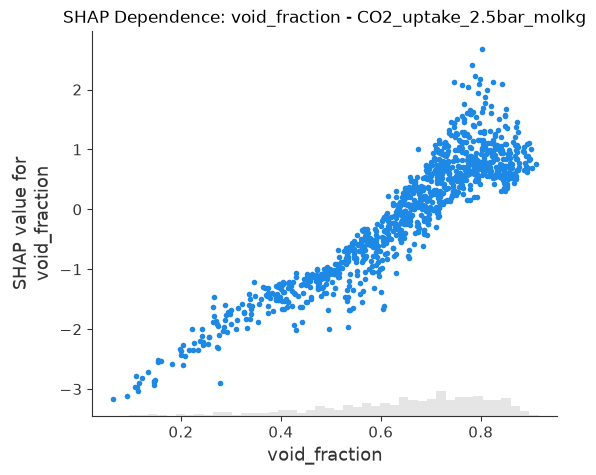

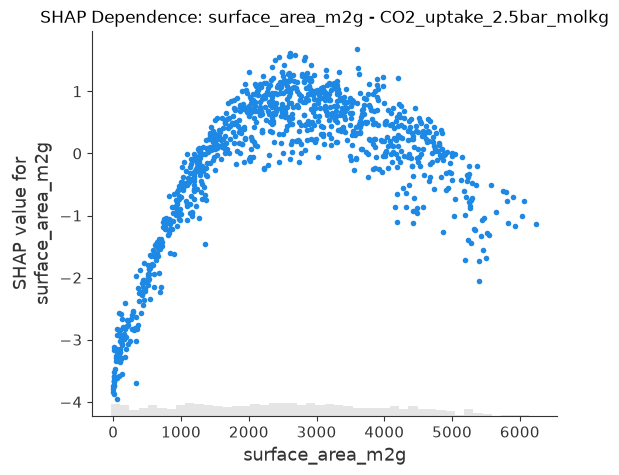

In [9]:
import matplotlib.pyplot as plt

for target in target_columns:
    shap_values = shap_values_by_target[target]

    # Explain the first sampled material at this pressure
    shap.plots.waterfall(shap_values[0], show=False)
    plt.title(f"SHAP Waterfall: {target}")
    plt.show()

    # Show each feature's effect at this pressure
    for feature in feature_columns:
        shap.plots.scatter(shap_values[:, feature], show=False)
        plt.title(f"SHAP Dependence: {feature} - {target}")
        plt.show()

## SHAP Interpretation Across CO₂ Pressures

The SHAP analysis shows that the structural features driving predicted CO₂ uptake change with pressure.

| Pressure | Feature importance by mean \|SHAP\| |
|---|---|
| **0.05 bar** | Surface area (0.41) > Void fraction (0.31) > PLD (0.14) > LCD (0.07) |
| **0.1 bar** | Surface area (0.43) > Void fraction (0.35) > PLD (0.26) > LCD (0.10) |
| **0.5 bar** | PLD (0.67) > Void fraction (0.55) > Surface area (0.47) > LCD (0.20) |
| **2.5 bar** | PLD (1.19) > Surface area (0.87) ≈ Void fraction (0.87) > LCD (0.31) |

### Surface Area

At low pressures (**0.05 and 0.1 bar**), surface area is the strongest model driver. 
Low-to-moderate surface areas increase predicted CO₂ uptake, with the largest positive
effects occurring approximately between **300–1000 m²/g**.

Above approximately **1500–2500 m²/g**, surface area generally shifts predictions
downward. Therefore, the model does not show a simple relationship in which increasing
surface area always increases CO₂ uptake.

### Void Fraction

Void fraction shows a generally positive relationship with predicted CO₂ uptake.
Low void fractions tend to produce negative SHAP values, while higher void fractions,
particularly above approximately **0.6**, tend to increase predicted uptake.

The importance of void fraction also increases as pressure increases.

### Pore Limiting Diameter (PLD)

PLD becomes the dominant structural feature at **0.5 and 2.5 bar**.

PLD values of approximately **3–5 Å** tend to make strong positive contributions to
predicted uptake. As PLD increases beyond approximately **6–7 Å**, its SHAP contribution
generally becomes negative.

This effect becomes particularly strong at **2.5 bar**, where PLD has the largest
mean absolute SHAP value of all four structural descriptors.

### Largest Cavity Diameter (LCD)

LCD is the least influential feature across all investigated pressures.

Nevertheless, it shows a similar pore-size pattern. Smaller-to-intermediate LCD values,
approximately **4–6 Å**, tend to increase predicted uptake, whereas LCD values above
approximately **7–8 Å** generally shift predictions downward.

### Individual Prediction

The waterfall plots provide a local explanation for an individual MOF from the test set.

For the selected material:

- `void_fraction = 0.333`
- `surface_area_m2g = 542.1`
- `pld = 3.75 Å`
- `lcd = 4.75 Å`

The contribution of each structural descriptor changes with pressure. For example,
the relatively small PLD can contribute positively to the prediction, whereas the
low void fraction can reduce predicted uptake.

The waterfall plot should therefore be interpreted as an explanation of **one MOF
prediction**, rather than as evidence of the overall behavior of the dataset.

## Overall Interpretation

SHAP analysis reveals a **pressure-dependent shift in the structural factors associated
with predicted CO₂ uptake**. At low pressure (**0.05–0.1 bar**), surface area is the
most influential structural descriptor, followed by void fraction. At higher pressure
(**0.5–2.5 bar**), pore limiting diameter becomes the dominant feature, while void
fraction and surface area remain important.

Across the investigated pressures, higher void fraction generally contributes positively
to predicted uptake. In contrast, PLD and LCD show an apparent optimal-range behavior:
small-to-intermediate pore diameters are associated with positive SHAP contributions,
whereas larger pore diameters generally reduce the model prediction. Surface area also
shows a non-monotonic relationship, with moderate values tending to increase predictions
and very high values tending to decrease them.

These results represent **model-based associations rather than causal relationships**.
The SHAP effects should also be interpreted carefully because the four structural
descriptors are correlated, particularly LCD, PLD, void fraction, and surface area.

## Comparison Across Pressures

The 0.01 bar result has the same feature ranking as the 0.05 and 0.1 bar models: surface area, void fraction, PLD, then LCD.

| Pressure | Surface area | Void fraction | PLD | LCD |
| --- | ---: | ---: | ---: | ---: |
| 0.01 bar | 0.23 | 0.18 | 0.04 | 0.02 |
| 0.05 bar | 0.41 | 0.31 | 0.14 | 0.07 |
| 0.1 bar | 0.43 | 0.35 | 0.26 | 0.10 |
| 0.5 bar | 0.47 | 0.55 | 0.67 | 0.20 |
| 2.5 bar | 0.87 | 0.87 | 1.19 | 0.31 |

Values are mean absolute SHAP values, so a larger value means the feature has a greater average effect on that model's prediction.

At 0.01, 0.05, and 0.1 bar, surface area is the main model driver, followed by void fraction. At these low pressures, low-to-moderate surface area tends to increase the predicted uptake, while very high surface area tends to lower it. Void fraction shows a consistent positive pattern: low void fraction reduces predicted uptake, whereas higher void fraction increases it.

At 0.5 bar, the importance shifts: PLD becomes the most influential feature, followed by void fraction and surface area. At 2.5 bar, PLD is clearly dominant. Small-to-intermediate PLD values, approximately 3-5 A, increase predicted uptake, whereas PLD above roughly 6-7 A lowers it. This negative effect of larger pore diameters becomes much stronger at higher pressure.

LCD remains the least important feature at every pressure. Its pattern is similar to PLD but weaker: values near 4-6 A are generally favorable, while larger LCD values tend to have a negative contribution.

## Conclusion

The SHAP results indicate a pressure-dependent transition in the structural factors governing predicted CO2 uptake. At very low pressure (0.01 bar), predicted CO2 is primarily associated with surface area and void fraction, suggesting that accessible adsorption surface and available pore volume are the most influential structural descriptors. From 0.05 to 0.1 bar, this same pattern remains, although the influence of pore size begins to increase. At 0.5 and 2.5 bar, pore limiting diameter becomes the dominant descriptor, demonstrating that pore-size matching is increasingly important under higher-pressure conditions. Across all pressures, higher void fraction generally increases predicted uptake. PLD and LCD show an optimal pore-size range, where small-to-intermediate pore diameters enhance uptake but larger pores reduce it. Therefore, the model suggests that designing MOFs for CO2 adsorption requires balancing accessible void volume and surface area at low pressure with appropriately constrained pore sizes at higher pressure.

**Caution:** SHAP magnitudes rise as pressure rises partly because uptake values and their variation are likely larger at higher pressures. The feature ranking within each pressure is the most reliable comparison. For a strict comparison of effect strength across pressures, normalize each target before training or divide the mean absolute SHAP values by that target's standard deviation.